# SIE job testing (stochastic explicit euler) with flux relaxation

In [ ]:
# import data.pwr_rei_template as pwr # nonsymmetric pwr pin 
import data.pwr_symmetric_template as pwr
import openmc
import openmc.deplete
import numpy as np
import copy
import pickle as pkl
import glob
import os
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
openmc.deplete.pool.USE_MULTIPROCESSING=False

from SIE import SIE
from Anderson import run_transport, run_transport_for_chain

from NuclideVectorMath import get_nuclides_for_transport, \
    get_depletion_materials_from_results_EOS, \
    chain_from_pkl, \
    depletable_mats_from_model, \
    relax_nuclides_from_files

In [ ]:
# Input stuff
micro_xs = chain_from_pkl(file='data/FINAL_CHAIN.pkl') # get xs from a reference file
chain_file = 'data/chain_casl_pwr.xml'
results_folder = 'results'
dt = [0.5, 1, 1.5, 2, 5, 10, 10, 10, 10,
25, 25, 25, 25,
25, 25, 25, 25,
25, 25, 25, 25] # up to 350 days
model = pwr.get_model()

# Computing the power density to use
fuel_r=0.3975
power_density = 104
power = power_density * 366  * np.pi * fuel_r**2

# Random stuff - non-strictly-input-based
depletion_materials = depletable_mats_from_model(model=model) # get from starting model
depl_id_list = [this.id for this in depletion_materials]

# Robbins Monro related
nsolves = 5 # number of transport solves/solution
sie = SIE()

In [ ]:
"""Start by performing t=0 transport"""
RESULTS_TRANSPORT = run_transport(model=model, power_tally_ids=depl_id_list) ## transport w/ batch-by-batch tally tracking
LATEST_FLUX = sie.get_final_tally(res=RESULTS_TRANSPORT, normalize_to=1.0)
sie.finalize_bos(x=LATEST_FLUX)


"""
Now iterating through time.
"""
the_eos_time = 0.0
for TIME_IDX, this_dt in enumerate(dt):
  # Time
  the_eos_time += this_dt

  # Set x and f(x)
  x = [] # X values from relaxed robbins monro algorithm
  fx = [] # Values from the actual transport solves (F(x)) --> fx

  # Solve f(x0)
  the_fx = sie.solve(x = LATEST_FLUX, 
                     tidx=TIME_IDX, iidx=0,
                     depl_mats=depletion_materials,
                     model=model, micro_xs=micro_xs,chain_file=chain_file,
                     dt=this_dt, power=power, depl_id_list=depl_id_list)

  # Track and update
  fx.append(copy.deepcopy(the_fx))  
  x.append(sie.get_relaxed_flux(fx=fx))
  LATEST_FLUX = copy.deepcopy(x[-1]) 

  # Now iterate across solves.
  for iidx in range(1, nsolves+1):
    the_fx = sie.solve(x=LATEST_FLUX, 
                       tidx=TIME_IDX, iidx=iidx,
                       depl_mats=depletion_materials,
                       model=model, micro_xs=micro_xs,chain_file=chain_file,
                       dt=this_dt, power=power, depl_id_list=depl_id_list)

    # track and update
    fx.append(copy.deepcopy(the_fx))  
    print(f"THE FX IS: {the_fx}")
    x.append(sie.get_relaxed_flux(fx=fx))
    print(f"THE RELAXED FLUX IS: {x[-1]}")
    LATEST_FLUX = copy.deepcopy(x[-1]) 

  # Advances depletion material definitions to EOS values for the next BU step since we are now done iterating
  sie.finalize(time=the_eos_time, x=x, fx=fx)
  sie.dump_to_pkl(name=f'sie_i{iidx}_t{TIME_IDX}')
  depletion_materials = get_depletion_materials_from_results_EOS(output_name=sie.depl_output, model=model)
  
    

In [ ]:
output_name = 'depl_step_s3_i0.h5'
results = openmc.deplete.Results(output_name)
results[-1].get_material(str('11')).id

In [ ]:
for i in range(1, 5):
  print(i) 

# SIE JOB version 2 (now the only version thgat we are testing, has nuclides and power relaxation)

[ 11.4375  34.3125  57.1875  80.0625 102.9375 125.8125 148.6875 171.5625
 194.4375 217.3125 240.1875 263.0625 285.9375 308.8125 331.6875 354.5625]


/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=3.
  warn(msg, IDWarning)
/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=5.
  warn(msg, IDWarning)
/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=7.
  warn(msg, IDWarning)
/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=9.
  warn(msg, IDWarning)
/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=11.
  warn(msg, IDWarning)
/Users/4yf/projects/MonteCarloXenon/.pixi/envs/de

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

...

/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=3.
  warn(msg, IDWarning)
/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=5.
  warn(msg, IDWarning)
/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=7.
  warn(msg, IDWarning)
/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=9.
  warn(msg, IDWarning)
/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=11.
  warn(msg, IDWarning)
/Users/4yf/projects/MonteCarloXenon/.pixi/envs/de

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=3.
  warn(msg, IDWarning)
/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=5.
  warn(msg, IDWarning)
/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=7.
  warn(msg, IDWarning)
/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=9.
  warn(msg, IDWarning)
/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=11.
  warn(msg, IDWarning)
/Users/4yf/projects/MonteCarloXenon/.pixi/envs/de

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

KeyboardInterrupt: 

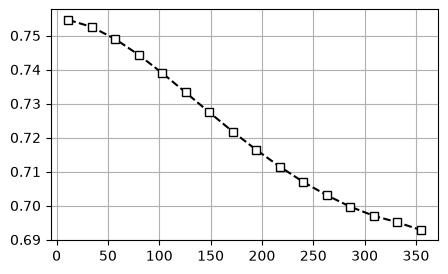

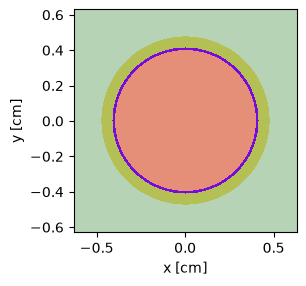

In [1]:
import data.pwr_rei_template as pwr
import openmc
import openmc.deplete
import numpy as np
import copy
import pickle as pkl
import glob
import os
import sys
import shutil
from pathlib import Path
import matplotlib.pyplot as plt

openmc.deplete.pool.USE_MULTIPROCESSING=False

"""
Setup logging
"""
import logging 
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s', filemode='a', filename="LOGGING.LOG")
logging.getLogger().setLevel(logging.DEBUG)

from SIE import SIE
from Anderson import run_transport, run_transport_for_chain, run_transport_standard

from NuclideVectorMath import get_nuclides_for_transport, \
    make_transport_material_library, \
    get_depletion_materials_from_results_EOS, \
    chain_from_pkl, \
    depletable_mats_from_model, \
    make_transport_material_library, \
    relax_nuclides_from_files

logging.info(f"Now running input....")


# Input stuff
micro_xs = chain_from_pkl(file='data/FINAL_CHAIN.pkl') # get xs from a reference file
chain_file = 'data/chain_casl_pwr.xml'
results_folder = 'results'
dt = [0.5, 1, 1.5, 2, 5, 10, 10, 10, 10,
25, 25, 25, 25,
25, 25, 25, 25,
25, 25, 25, 25] # up to 350 days
model = pwr.get_model()

# Computing the power density to use
fuel_r=0.3975
power_density = 104
power = power_density * 366  * np.pi * fuel_r**2

# Random stuff - non-strictly-input-based
depletion_materials = depletable_mats_from_model(model=model) # get from starting model
depl_id_list = [this.id for this in depletion_materials]

# Robbins Monro related
nsolves = 4 # number of transport solves/solution
sie = SIE(relax_N=False, relax_F=True)


"""Start by performing t=0 transport"""
sie.initialize_bos()
RESULTS_TRANSPORT = run_transport_standard(model=model, power_tally_ids=depl_id_list) ## transport w/ batch-by-batch tally tracking
LATEST_FLUX = sie.get_final_tally(res=RESULTS_TRANSPORT, normalize_to=1.0)
sie.set_bos_solution(x=LATEST_FLUX)
sie.finalize_bos()
sie.dump_to_pkl(name=f'sie_i{0}_t{0}.pkl')

"""
Now iterating through time.
"""
the_eos_time = 0.0
for _tidx, this_dt in enumerate(dt):
  
  # Time
  TIME_IDX = _tidx + 1
  the_eos_time += this_dt
  sie.initialize_step(time=the_eos_time)
  final_solve = False

  # Now iterate across solves.
  for iidx in range(0, nsolves):
    if iidx == nsolves-1:
      final_solve = True
    x = sie.solve(x=LATEST_FLUX, 
                  tidx=TIME_IDX, iidx=iidx, time=the_eos_time,
                  depl_mats=depletion_materials,
                  model=model, micro_xs=micro_xs,chain_file=chain_file,
                  dt=this_dt, power=power, depl_id_list=depl_id_list, final_solve=final_solve)
    # TODO: make sure relaxation of the fluxes is carried out correctly here. []
    # TODO: make sure that we are properly iterating power and the nuclide vector here. [x]
    # TODO: make sure that we are correctly doing predictor separation here [x] 
    # TODO: make sure that we can set nsolves to 1 and get the correct behavior here. [x]

    # track and update
    LATEST_FLUX = copy.deepcopy(x) 


  # Advances depletion material definitions to EOS values for the next BU step since we are now done iterating
  sie.finalize()
  sie.dump_to_pkl(name=f'results/sie_i{iidx}_t{TIME_IDX}.pkl')
  depletion_materials = get_depletion_materials_from_results_EOS(output_name=sie.depl_output_name, model=model)
  
    


In [15]:
this = np.zeros(16)
n  = 4
for idx in range(n):
  this += sie.fx[0.5][idx]/n
print(this)

[0.01407936 0.03522638 0.05612225 0.07387809 0.08385207 0.08893042
 0.09184992 0.08918155 0.0869227  0.08425911 0.07755749 0.07039522
 0.05960596 0.04660276 0.02953405 0.01200268]


In [4]:
sie.get_relaxed_flux(sie.fx[0.5])

array([0.01407936, 0.03522638, 0.05612225, 0.07387809, 0.08385207,
       0.08893042, 0.09184992, 0.08918155, 0.0869227 , 0.08425911,
       0.07755749, 0.07039522, 0.05960596, 0.04660276, 0.02953405,
       0.01200268])

In [16]:
LATEST_FLUX

array([0.01407936, 0.03522638, 0.05612225, 0.07387809, 0.08385207,
       0.08893042, 0.09184992, 0.08918155, 0.0869227 , 0.08425911,
       0.07755749, 0.07039522, 0.05960596, 0.04660276, 0.02953405,
       0.01200268])

In [ ]:
sie._N[0.5][0][0, 'U235']

In [ ]:
sie._N[0.5][0].index_mat

In [ ]:
sie.get_N_by_iteration(time=0.5, nuc='U235')

In [ ]:
# Checking that N is properly relaxed via the RM algorithm
gn = sie.get_gN_by_iteration(time=0.5, nuc='U235')
nn = sie.get_N_by_iteration(time=0.5, nuc="U235")

the_list = []
for key in gn.keys():
  the_list.append(gn[key]['43'])
  print(f"u235 GN {key} = {gn[key]['43']}")

for key in gn.keys():
  print(f"u235 NN {key} = {nn[key]['43']}")

for i in range(1,len(the_list)+1):
  print("the list mean = ", np.mean(the_list[0:i]))

In [ ]:
sie.get_N_by_time(time=0.5, nuc='U235')